<a href="https://colab.research.google.com/github/KowshiqKatta/Generative-AI/blob/main/LangGraph/human_in_the_loop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install langchain_openai
from typing import Annotated

from langchain_openai import ChatOpenAI
from langchain_core.messages import AnyMessage, AIMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 3.7 MB/s eta 0:00:00


In [3]:
load_dotenv()

False

In [5]:
import os

# Replace 'YOUR_OPENAI_API_KEY' with your actual OpenAI API key
os.environ["OPENAI_API_KEY"] = "YOUR-API-KEY"

llm = ChatOpenAI(model="gpt-4.1-mini")

In [6]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [7]:
def chat_node(state: ChatState):

    decision = interrupt({
        "type": "approval",
        "reason": "Model is about to answer a user question.",
        "question": state["messages"][-1].content,
        "instruction": "Approve this question? yes/no"
    })

    if decision["approved"] == 'no':
        return {"messages": [AIMessage(content="Not approved.")]}

    else:
        response = llm.invoke(state["messages"])
        return {"messages": [response]}

In [8]:
# 3. Build the graph: START -> chat -> END
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)

builder.add_edge(START, "chat")
builder.add_edge("chat", END)

# Checkpointer is required for interrupts
checkpointer = MemorySaver()

# Compile the app
app = builder.compile(checkpointer=checkpointer)

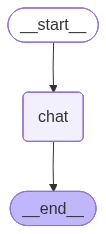

In [9]:
app

In [19]:
# Create a new thread id for this conversation
config = {"configurable": {"thread_id": '1234'}}

# ---- STEP 1: user asks a question ----
initial_input = {
    "messages": [
        ("user", "Explain gradient descent in very simple terms.")
    ]
}

# Invoke the graph for the first time
result = app.invoke(initial_input, config=config)

In [20]:
result

{'messages': [HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='3fd67b97-ba05-4294-946f-f9239d5bfb6b'),
  AIMessage(content='Not approved.', additional_kwargs={}, response_metadata={}, id='619d1ee7-3ee7-44f9-88f0-b3b74f6480bf', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='f85525e9-61d0-4a06-b9f1-0c33d058c9a7')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'Model is about to answer a user question.', 'question': 'Explain gradient descent in very simple terms.', 'instruction': 'Approve this question? yes/no'}, id='20d0d01a4b53813750ab01be992fa1e4')]}

In [21]:
message = result['__interrupt__'][0].value
message

{'type': 'approval',
 'reason': 'Model is about to answer a user question.',
 'question': 'Explain gradient descent in very simple terms.',
 'instruction': 'Approve this question? yes/no'}

In [22]:
user_input = input(f"\nBackend message - {message} \n Approve this question? (y/n): ")


Backend message - {'type': 'approval', 'reason': 'Model is about to answer a user question.', 'question': 'Explain gradient descent in very simple terms.', 'instruction': 'Approve this question? yes/no'} 
 Approve this question? (y/n): yes


In [23]:
# Resume the graph with the approval decision
final_result = app.invoke(
    Command(resume={"approved": user_input}),
    config=config,
)

In [24]:
print(final_result["messages"][-1].content)

Sure! Imagine you are standing on top of a hill, and it’s very foggy, so you can’t see far around you. Your goal is to find the lowest point in the area — the bottom of a valley.

Gradient descent is a way to do this by taking small steps downhill:

1. Look around your feet to see which direction slopes downward the most.
2. Take a small step in that direction.
3. Repeat: from your new spot, again find the steepest downward direction and step that way.

By doing this over and over, you slowly move down the hill until you can’t go any lower. In math or computer science, this helps find the best solution to a problem by minimizing errors or costs.
